<a href="https://colab.research.google.com/github/IT22283344/DL_Assignment/blob/piuminda/finalresnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1 — Mount Google Drive and install kaggle
from google.colab import drive
drive.mount('/content/drive')

!pip install kaggle

Mounted at /content/drive


In [ ]:
from google.colab import files
import os

# Upload your kaggle.json file
print("Please upload your kaggle.json file:")
files.upload()


Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"enjoyfree","key":"ec656a13e6ce47db21def0ce4e767599"}'}

In [ ]:
# Setup Kaggle directory and permissions
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("✅ Kaggle API setup complete!")

✅ Kaggle API setup complete!


In [ ]:
# Cell 3 — Download waste classification dataset
import os

# Create directory for dataset
dataset_dir = "/content/drive/MyDrive/SE4050/assignment"
os.makedirs(dataset_dir, exist_ok=True)

In [ ]:
# Download dataset
!kaggle datasets download -d techsash/waste-classification-data -p "{dataset_dir}"

print("✅ Dataset download complete!")

Dataset URL: https://www.kaggle.com/datasets/techsash/waste-classification-data
License(s): CC-BY-SA-4.0
waste-classification-data.zip: Skipping, found more recently modified local copy (use --force to force download)
✅ Dataset download complete!


In [ ]:
# Cell 4 — Extract the dataset
import zipfile
import os

zip_path = "/content/drive/MyDrive/SE4050/assignment/waste-classification-data.zip"
extract_path = "/content/drive/MyDrive/SE4050/assignment/waste-classification-data"

# Check if zip file exists before extracting
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("✅ Dataset extracted successfully to:", extract_path)
else:
    print("❌ File not found at:", zip_path)

✅ Dataset extracted successfully to: /content/drive/MyDrive/SE4050/assignment/waste-classification-data


In [ ]:
# Cell 5 — Verify dataset structure
import os

dataset_path = "/content/drive/MyDrive/SE4050/assignment/waste-classification-data/DATASET"

train_path = os.path.join(dataset_path, "TRAIN")
test_path = os.path.join(dataset_path, "TEST")

# Verify paths
print("TRAIN path exists:", os.path.exists(train_path))
print("TEST path exists:", os.path.exists(test_path))

# Check what classes are available
if os.path.exists(train_path):
    train_classes = os.listdir(train_path)
    print("Training classes:", train_classes)

if os.path.exists(test_path):
    test_classes = os.listdir(test_path)
    print("Testing classes:", test_classes)

print("\n✅ Dataset verification complete!")

TRAIN path exists: True
TEST path exists: True
Training classes: ['O', 'R']
Testing classes: ['O', 'R']

✅ Dataset verification complete!


In [ ]:
# Cell 6 — Import all required libraries
import os, shutil, random, itertools, math, json
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import itertools
import cv2

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_fscore_support
from sklearn.utils import class_weight

# Set random seeds for reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [ ]:
# Cell 7 — Configure paths and parameters for Google Drive
DATA_ROOT = Path("/content/drive/MyDrive/SE4050/assignment/waste-classification-data/DATASET")
TRAIN_DIR = DATA_ROOT / "TRAIN"
TEST_DIR = DATA_ROOT / "TEST"

# Create output directory in Google Drive
OUTPUT_DIR = Path("/content/drive/MyDrive/SE4050/assignment/output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Image and training parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20

print("📁 Path Configuration:")
print("Train directory:", TRAIN_DIR)
print("Test directory:", TEST_DIR)
print("Output directory:", OUTPUT_DIR)
print("Train exists:", TRAIN_DIR.exists())
print("Test exists:", TEST_DIR.exists())
print("Output exists:", OUTPUT_DIR.exists())

📁 Path Configuration:
Train directory: /content/drive/MyDrive/SE4050/assignment/waste-classification-data/DATASET/TRAIN
Test directory: /content/drive/MyDrive/SE4050/assignment/waste-classification-data/DATASET/TEST
Output directory: /content/drive/MyDrive/SE4050/assignment/output
Train exists: True
Test exists: True
Output exists: True


In [ ]:
# Cell 8 — Define class mapping for binary classification
CLASS_MAPPING = {
    'O': 'organic',      # Organic waste
    'R': 'recycle'       # Recyclable waste
}

print("🗂️ Class Mapping:")
for orig_class, binary_label in CLASS_MAPPING.items():
    print(f"  {orig_class} → {binary_label}")

# Verify the classes exist in dataset
if TRAIN_DIR.exists():
    actual_classes = [p.name for p in TRAIN_DIR.iterdir() if p.is_dir()]
    print("\n📊 Actual classes found in dataset:", actual_classes)

    # Check if all classes are mapped
    for cls in actual_classes:
        if cls not in CLASS_MAPPING:
            print(f"⚠️ Warning: Class '{cls}' not mapped in CLASS_MAPPING!")

🗂️ Class Mapping:
  O → organic
  R → recycle

📊 Actual classes found in dataset: ['O', 'R']


In [ ]:
# Cell 9 — Create binary dataset structure
def build_binary_dataset(source_root, dest_root, class_map):
    """
    source_root: Path containing subfolders (each class)
    dest_root: Path to create binary folders inside (dest_root/train, dest_root/val, dest_root/test)
    class_map: dict mapping original class names -> 'organic' or 'recycle'
    """
    source_root = Path(source_root)
    dest_root = Path(dest_root)

    # Create directory structure
    for split in ["train", "val", "test"]:
        (dest_root / split / "organic").mkdir(parents=True, exist_ok=True)
        (dest_root / split / "recycle").mkdir(parents=True, exist_ok=True)

    # Process TRAIN data (split into train/val)
    train_pairs = []
    for orig_class in (source_root / "TRAIN").iterdir():
        if not orig_class.is_dir():
            continue
        label = class_map.get(orig_class.name)
        if label is None:
            print(f"Skipping unmapped class: {orig_class.name}")
            continue
        for f in orig_class.iterdir():
            if f.is_file() and f.suffix.lower() in [".jpg", ".jpeg", ".png"]:
                train_pairs.append((f, label))

    # Shuffle and split train into train/val (80/20)
    random.shuffle(train_pairs)
    n_train = int(0.8 * len(train_pairs))

    print(f"📊 Splitting {len(train_pairs)} training images:")
    print(f"  - Train: {n_train} images")
    print(f"  - Validation: {len(train_pairs) - n_train} images")

    for i, (f, label) in enumerate(train_pairs):
        if i < n_train:
            split = "train"
        else:
            split = "val"
        dest = dest_root / split / label
        shutil.copy(f, dest / f.name)

    # Process TEST data
    test_count = 0
    for orig_class in (source_root / "TEST").iterdir():
        if not orig_class.is_dir():
            continue
        label = class_map.get(orig_class.name)
        if label is None:
            continue
        for f in orig_class.iterdir():
            if f.is_file() and f.suffix.lower() in [".jpg", ".jpeg", ".png"]:
                dest = dest_root / "test" / label
                shutil.copy(f, dest / f.name)
                test_count += 1

    print(f"  - Test: {test_count} images")
    print(f"✅ Binary dataset created at {dest_root}")

# Create binary dataset
BINARY_ROOT = Path("/content/drive/MyDrive/SE4050/assignment/data_binary")
build_binary_dataset(DATA_ROOT, BINARY_ROOT, CLASS_MAPPING)

📊 Splitting 22564 training images:
  - Train: 18051 images
  - Validation: 4513 images
  - Test: 2513 images
✅ Binary dataset created at /content/drive/MyDrive/SE4050/assignment/data_binary


In [ ]:
# Cell 10 — Verify binary dataset structure
TRAIN_BIN = BINARY_ROOT / "train"
VAL_BIN = BINARY_ROOT / "val"
TEST_BIN = BINARY_ROOT / "test"

print("📁 Binary Dataset Structure:")
print(f"Train: {TRAIN_BIN} - exists: {TRAIN_BIN.exists()}")
print(f"Val: {VAL_BIN} - exists: {VAL_BIN.exists()}")
print(f"Test: {TEST_BIN} - exists: {TEST_BIN.exists()}")

# Count images in each split
print("\n📊 Image Counts:")
for split_name, split_path in [("Train", TRAIN_BIN), ("Val", VAL_BIN), ("Test", TEST_BIN)]:
    if split_path.exists():
        organic_count = len(list((split_path / "organic").glob("*.*")))
        recycle_count = len(list((split_path / "recycle").glob("*.*")))
        total = organic_count + recycle_count
        print(f"  {split_name}: Organic={organic_count}, Recycle={recycle_count}, Total={total}")

📁 Binary Dataset Structure:
Train: /content/drive/MyDrive/SE4050/assignment/data_binary/train - exists: True
Val: /content/drive/MyDrive/SE4050/assignment/data_binary/val - exists: True
Test: /content/drive/MyDrive/SE4050/assignment/data_binary/test - exists: True

📊 Image Counts:
  Train: Organic=10067, Recycle=7984, Total=18051
  Val: Organic=2498, Recycle=2015, Total=4513
  Test: Organic=1401, Recycle=1112, Total=2513


In [ ]:
# Cell 11 — Create ImageDataGenerators with data augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=resnet_preprocess,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=False,
    fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator(preprocessing_function=resnet_preprocess)

# Create data generators
train_gen = train_datagen.flow_from_directory(
    TRAIN_BIN,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    seed=SEED,
    shuffle=True
)

val_gen = val_test_datagen.flow_from_directory(
    VAL_BIN,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    seed=SEED,
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    TEST_BIN,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    seed=SEED,
    shuffle=False
)

print("✅ Data generators created successfully!")
print("Class indices:", train_gen.class_indices)

Found 18051 images belonging to 2 classes.
Found 4513 images belonging to 2 classes.
Found 2513 images belonging to 2 classes.
✅ Data generators created successfully!
Class indices: {'organic': 0, 'recycle': 1}


In [ ]:
# Cell 12 — Compute class weights for imbalanced data
y_train = train_gen.classes
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print("⚖️ Class weights:", class_weight_dict)

⚖️ Class weights: {0: np.float64(0.8965431608224893), 1: np.float64(1.1304483967935872)}


In [ ]:
# Cell 13 — Build ResNet50-based model
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
base_model.trainable = False  # Freeze base model initially

# Build custom classifier head
inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs)

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

print("✅ Model built successfully!")
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
✅ Model built successfully!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# Cell 14 — Configure training callbacks
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    OUTPUT_DIR / "best_model.h5",
    monitor="val_auc",
    mode="max",
    save_best_only=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    verbose=1
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=6,
    restore_best_weights=True,
    verbose=1
)

tensorboard_cb = keras.callbacks.TensorBoard(
    log_dir=str(OUTPUT_DIR / "logs")
)

print("✅ Training callbacks configured!")

✅ Training callbacks configured!


In [ ]:
# Cell 15 — Train with frozen base model
print("🚀 Starting Phase 1: Training with frozen base model...")

history1 = model.fit(
    train_gen,
    epochs=8,
    validation_data=val_gen,
    callbacks=[checkpoint_cb, reduce_lr, early_stop, tensorboard_cb],
    class_weight=class_weight_dict,
    verbose=1
)

print("✅ Phase 1 training completed!")

🚀 Starting Phase 1: Training with frozen base model...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 643ms/step - accuracy: 0.8265 - auc: 0.8989 - loss: 0.3795
Epoch 1: val_auc improved from -inf to 0.98634, saving model to /content/drive/MyDrive/SE4050/assignment/output/best_model.h5


565/565 ━━━━━━━━━━━━━━━━━━━━ 423s 722ms/step - accuracy: 0.8266 - auc: 0.8990 - loss: 0.3793 - val_accuracy: 0.9446 - val_auc: 0.9863 - val_loss: 0.1476 - learning_rate: 1.0000e-04
Epoch 2/8
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - accuracy: 0.9297 - auc: 0.9766 - loss: 0.1900
Epoch 2: val_auc improved from 0.98634 to 0.98936, saving model to /content/drive/MyDrive/SE4050/assignment/output/best_model.h5


565/565 ━━━━━━━━━━━━━━━━━━━━ 308s 545ms/step - accuracy: 0.9297 - auc: 0.9766 - loss: 0.1900 - val_accuracy: 0.9537 - val_auc: 0.9894 - val_loss: 0.1299 - learning_rate: 1.0000e-04
Epoch 3/8
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 512ms/step - accuracy: 0.9321 - auc: 0.9792 - loss: 0.1802
Epoch 3: val_auc improved from 0.98936 to 0.99061, saving model to /content/drive/MyDrive/SE4050/assignment/output/best_model.h5


...

565/565 ━━━━━━━━━━━━━━━━━━━━ 315s 557ms/step - accuracy: 0.9389 - auc: 0.9832 - loss: 0.1620 - val_accuracy: 0.9541 - val_auc: 0.9915 - val_loss: 0.1202 - learning_rate: 1.0000e-04
Epoch 5/8
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 517ms/step - accuracy: 0.9403 - auc: 0.9834 - loss: 0.1589
Epoch 5: val_auc improved from 0.99154 to 0.99197, saving model to /content/drive/MyDrive/SE4050/assignment/output/best_model.h5


565/565 ━━━━━━━━━━━━━━━━━━━━ 316s 559ms/step - accuracy: 0.9403 - auc: 0.9834 - loss: 0.1589 - val_accuracy: 0.9557 - val_auc: 0.9920 - val_loss: 0.1154 - learning_rate: 1.0000e-04
Epoch 6/8
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 540ms/step - accuracy: 0.9429 - auc: 0.9851 - loss: 0.1513
Epoch 6: val_auc improved from 0.99197 to 0.99240, saving model to /content/drive/MyDrive/SE4050/assignment/output/best_model.h5


565/565 ━━━━━━━━━━━━━━━━━━━━ 328s 580ms/step - accuracy: 0.9429 - auc: 0.9851 - loss: 0.1513 - val_accuracy: 0.9601 - val_auc: 0.9924 - val_loss: 0.1110 - learning_rate: 1.0000e-04
Epoch 7/8
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 514ms/step - accuracy: 0.9474 - auc: 0.9877 - loss: 0.1384
Epoch 7: val_auc improved from 0.99240 to 0.99266, saving model to /content/drive/MyDrive/SE4050/assignment/output/best_model.h5


565/565 ━━━━━━━━━━━━━━━━━━━━ 314s 555ms/step - accuracy: 0.9474 - auc: 0.9877 - loss: 0.1384 - val_accuracy: 0.9583 - val_auc: 0.9927 - val_loss: 0.1093 - learning_rate: 1.0000e-04
Epoch 8/8
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - accuracy: 0.9532 - auc: 0.9893 - loss: 0.1279
Epoch 8: val_auc improved from 0.99266 to 0.99323, saving model to /content/drive/MyDrive/SE4050/assignment/output/best_model.h5


565/565 ━━━━━━━━━━━━━━━━━━━━ 314s 555ms/step - accuracy: 0.9532 - auc: 0.9893 - loss: 0.1279 - val_accuracy: 0.9628 - val_auc: 0.9932 - val_loss: 0.1034 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 8.
✅ Phase 1 training completed!


In [ ]:
# Cell 16 — Fine-tune with unfrozen layers
print("🔧 Starting Phase 2: Fine-tuning with unfrozen layers...")

# Unfreeze last 20 layers of base model
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Recompile with lower learning rate
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

# Continue training
history2 = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=[checkpoint_cb, reduce_lr, early_stop, tensorboard_cb],
    class_weight=class_weight_dict,
    verbose=1
)

print("✅ Phase 2 training completed!")

🔧 Starting Phase 2: Fine-tuning with unfrozen layers...
Epoch 1/20
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 519ms/step - accuracy: 0.9460 - auc: 0.9877 - loss: 0.1378
Epoch 1: val_auc did not improve from 0.99323
565/565 ━━━━━━━━━━━━━━━━━━━━ 357s 597ms/step - accuracy: 0.9460 - auc: 0.9877 - loss: 0.1378 - val_accuracy: 0.9592 - val_auc: 0.9931 - val_loss: 0.1056 - learning_rate: 1.0000e-05
Epoch 2/20
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - accuracy: 0.9553 - auc: 0.9908 - loss: 0.1175
Epoch 2: val_auc did not improve from 0.99323
565/565 ━━━━━━━━━━━━━━━━━━━━ 306s 542ms/step - accuracy: 0.9553 - auc: 0.9908 - loss: 0.1175 - val_accuracy: 0.9637 - val_auc: 0.9932 - val_loss: 0.0982 - learning_rate: 1.0000e-05
Epoch 3/20
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.9645 - auc: 0.9940 - loss: 0.0968
Epoch 3: val_auc improved from 0.99323 to 0.99374, saving model to /content/drive/MyDrive/SE4050/assignment/output/best_model.h5


565/565 ━━━━━━━━━━━━━━━━━━━━ 307s 543ms/step - accuracy: 0.9645 - auc: 0.9940 - loss: 0.0968 - val_accuracy: 0.9650 - val_auc: 0.9937 - val_loss: 0.0958 - learning_rate: 1.0000e-05
Epoch 4/20
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.9690 - auc: 0.9949 - loss: 0.0859
Epoch 4: val_auc did not improve from 0.99374
565/565 ━━━━━━━━━━━━━━━━━━━━ 306s 541ms/step - accuracy: 0.9690 - auc: 0.9949 - loss: 0.0859 - val_accuracy: 0.9645 - val_auc: 0.9935 - val_loss: 0.0953 - learning_rate: 1.0000e-05
Epoch 5/20
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 508ms/step - accuracy: 0.9736 - auc: 0.9966 - loss: 0.0723
Epoch 5: val_auc did not improve from 0.99374
565/565 ━━━━━━━━━━━━━━━━━━━━ 308s 545ms/step - accuracy: 0.9736 - auc: 0.9966 - loss: 0.0723 - val_accuracy: 0.9654 - val_auc: 0.9932 - val_loss: 0.0973 - learning_rate: 1.0000e-05
Epoch 6/20
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - accuracy: 0.9783 - auc: 0.9974 - loss: 0.0630
Epoch 6: val_auc did not improve from 0.99374
565/565 ━━━━━

In [ ]:
# Cell 17 — Save final model and training history
model.save(OUTPUT_DIR / "resnet50_waste_binary_full.h5")
model.save_weights(str(OUTPUT_DIR / "resnet50.weights.h5"))


# Save training history
import pickle
with open(OUTPUT_DIR / "training_history.pkl", "wb") as f:
    pickle.dump({
        "phase1_history": history1.history,
        "phase2_history": history2.history
    }, f)

print("💾 Model and training history saved successfully!")
print("Saved files:")
for file in OUTPUT_DIR.iterdir():
    print(f"  - {file.name}")

💾 Model and training history saved successfully!
Saved files:
  - logs
  - best_model.h5
  - resnet50_waste_binary_full.h5
  - resnet50.weights.h5
  - training_history.pkl


In [ ]:
# Cell 18 — Comprehensive evaluation on test set
print("📊 Evaluating on test set...")

# Get predictions
test_gen.reset()
preds = model.predict(test_gen, verbose=1)
y_true = test_gen.classes
y_prob = preds.flatten()
y_pred = (y_prob >= 0.5).astype(int)

# Calculate and print metrics
print("\n" + "="*60)
print("📈 CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred, target_names=list(test_gen.class_indices.keys())))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("\n🎯 CONFUSION MATRIX:")
print(cm)

# Precision, Recall, F1
p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
print(f"\n📋 Precision: {p:.4f}  Recall: {r:.4f}  F1-Score: {f1:.4f}")

# ROC AUC
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)
print(f"📊 ROC AUC: {roc_auc:.4f}")

📊 Evaluating on test set...
79/79 ━━━━━━━━━━━━━━━━━━━━ 23s 229ms/step

📈 CLASSIFICATION REPORT
              precision    recall  f1-score   support

     organic       0.89      0.99      0.94      1401
     recycle       0.98      0.85      0.91      1112

    accuracy                           0.93      2513
   macro avg       0.94      0.92      0.93      2513
weighted avg       0.93      0.93      0.93      2513


🎯 CONFUSION MATRIX:
[[1386   15]
 [ 163  949]]

📋 Precision: 0.9844  Recall: 0.8534  F1-Score: 0.9143
📊 ROC AUC: 0.9861


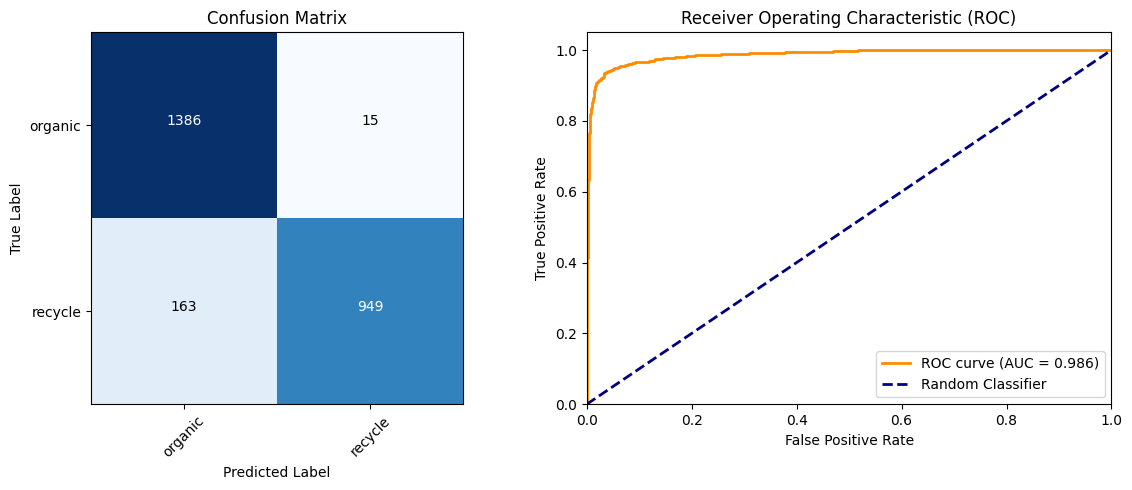

In [ ]:
# Cell 19 — Plot confusion matrix and ROC curve
plt.figure(figsize=(12, 5))

# Confusion Matrix
plt.subplot(1, 2, 1)
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
tick_marks = np.arange(len(test_gen.class_indices))
plt.xticks(tick_marks, list(test_gen.class_indices.keys()), rotation=45)
plt.yticks(tick_marks, list(test_gen.class_indices.keys()))

# Add text annotations
thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, f"{cm[i, j]}",
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# ROC Curve
plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [ ]:
# Cell 20 — Create directory for new test images
NEW_IMAGES_DIR = Path("/content/drive/MyDrive/SE4050/assignment/new_images")
NEW_IMAGES_DIR.mkdir(parents=True, exist_ok=True)

print("📁 Created directory for new images:", NEW_IMAGES_DIR)
print("💡 You can now upload test images to this folder for prediction")

📁 Created directory for new images: /content/drive/MyDrive/SE4050/assignment/new_images
💡 You can now upload test images to this folder for prediction


In [ ]:
# Cell 21 — Inference function for single images
from tensorflow.keras.preprocessing import image

def predict_image(img_path, model, target_size=IMG_SIZE, thresh=0.5):
    """Predict whether an image is organic or recyclable"""
    img = image.load_img(img_path, target_size=target_size)
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = resnet_preprocess(x)
    p = model.predict(x)[0][0]
    label = "recycle" if p >= thresh else "organic"
    return p, label, img

print("✅ Single image prediction function ready!")

✅ Single image prediction function ready!


In [ ]:
# Cell 22 — Batch prediction for multiple images
def batch_predict_images(folder_path, model, threshold=0.5):
    """Predict all images in a folder"""
    results = []
    folder_path = Path(folder_path)

    if not folder_path.exists():
        print(f"❌ Folder {folder_path} does not exist!")
        return pd.DataFrame()

    image_files = list(folder_path.glob("*.*"))
    image_files = [f for f in image_files if f.suffix.lower() in ['.jpg', '.jpeg', '.png']]

    if not image_files:
        print("❌ No images found in folder!")
        return pd.DataFrame()

    print(f"🔍 Found {len(image_files)} images. Predicting...")

    for img_path in tqdm(image_files):
        try:
            prob, label, _ = predict_image(str(img_path), model, thresh=threshold)
            results.append({
                "filename": img_path.name,
                "probability": float(prob),
                "prediction": label,
                "confidence": f"{prob:.3f}"
            })
        except Exception as e:
            print(f"❌ Error processing {img_path.name}: {e}")

    return pd.DataFrame(results)

print("✅ Batch prediction function ready!")

✅ Batch prediction function ready!


🧪 Improved prediction with detailed analysis...
Found 3 images for testing.

🔍 Class mapping reminder: 0=organic, 1=recycle
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

📊 bottle.jpeg:
   Raw probability: 1.000
   Prediction: RECYCLABLE
   Confidence: 1.000
   Threshold: 0.6


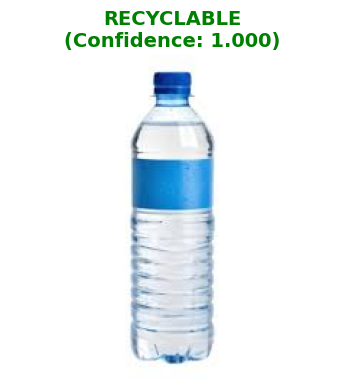


📊 organic.jpeg:
   Raw probability: 0.000
   Prediction: ORGANIC
   Confidence: 1.000
   Threshold: 0.6


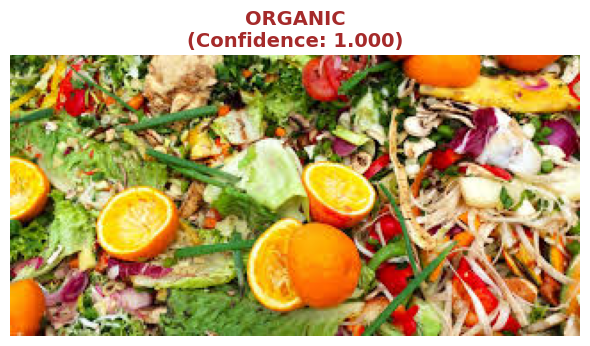


📊 fruit.jpeg:
   Raw probability: 0.000
   Prediction: ORGANIC
   Confidence: 1.000
   Threshold: 0.6


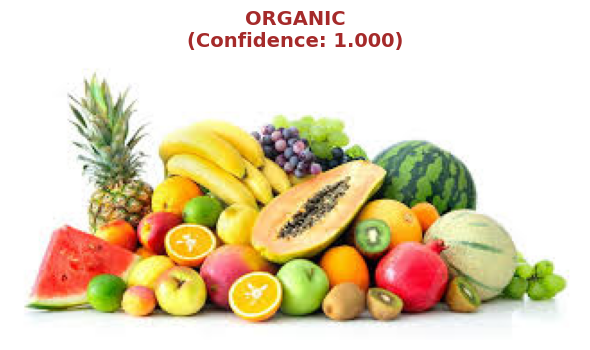

In [ ]:
# Cell 23a — Improved prediction with better analysis
print("🧪 Improved prediction with detailed analysis...")

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Get all valid image files
image_files = list(NEW_IMAGES_DIR.glob("*.*"))
image_files = [f for f in image_files if f.suffix.lower() in ['.jpg', '.jpeg', '.png']]

if not image_files:
    print("💡 No test images found. Upload images to:", NEW_IMAGES_DIR)
else:
    print(f"Found {len(image_files)} images for testing.")
    print("\n🔍 Class mapping reminder: 0=organic, 1=recycle")

    images_array = []
    pil_images = []

    # Preprocess all images first
    for img_file in image_files:
        img = Image.open(img_file).convert("RGB")
        pil_images.append(img)
        img_resized = img.resize((IMG_SIZE, IMG_SIZE))
        img_array = np.array(img_resized)
        images_array.append(img_array)

    # Convert to NumPy array and preprocess for ResNet50
    images_array = np.stack(images_array, axis=0)
    images_array = resnet_preprocess(images_array)  # Use ResNet50 preprocessing

    # Batch prediction
    preds = model.predict(images_array, verbose=1)

    # Display results with better analysis
    for i, img_file in enumerate(image_files):
        prob = float(preds[i][0])

        # Adjust threshold for better organic detection
        # Since we have more organic samples, we can be more conservative
        threshold = 0.6  # Increased threshold for recyclable classification

        if prob >= threshold:
            label = "RECYCLABLE"
            color = "green"
            confidence = prob
        else:
            label = "ORGANIC"
            color = "brown"
            confidence = 1 - prob  # Confidence for organic class

        print(f"\n📊 {img_file.name}:")
        print(f"   Raw probability: {prob:.3f}")
        print(f"   Prediction: {label}")
        print(f"   Confidence: {confidence:.3f}")
        print(f"   Threshold: {threshold}")

        plt.figure(figsize=(6, 4))
        plt.imshow(pil_images[i])
        plt.title(f"{label}\n(Confidence: {confidence:.3f})", color=color, fontsize=14, fontweight='bold')
        plt.axis("off")
        plt.tight_layout()
        plt.show()

In [ ]:
# Cell 24 — Retrain with focus on improving organic detection
print("🔄 Retraining model with focus on organic class...")

# Reload the best model for retraining
model = keras.models.load_model(OUTPUT_DIR / "best_model.h5")

# Unfreeze more layers for better feature learning
base_model = model.layers[1]
base_model.trainable = True
for layer in base_model.layers[:-40]:  # Unfreeze more layers
    layer.trainable = False

# Recompile with class-weighted loss focus
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc"),
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)

# Custom callback to monitor organic class performance
class OrganicFocusCallback(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        # Test on a small batch to check organic detection
        test_batch = next(test_gen)
        predictions = self.model.predict(test_batch[0], verbose=0)
        organic_indices = np.where(test_batch[1] == 0)[0]  # Organic class indices
        if len(organic_indices) > 0:
            organic_acc = np.mean((predictions[organic_indices] < 0.5).astype(int) == test_batch[1][organic_indices])
            print(f" - Organic detection accuracy: {organic_acc:.3f}")

# Retrain with focus on organic class
print("🎯 Additional training with organic class focus...")
history_fine = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=[
        OrganicFocusCallback(),
        keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
    ],
    class_weight=class_weight_dict,
    verbose=1
)

# Save the improved model
model.save(OUTPUT_DIR / "resnet50_improved_organic.h5")
print("✅ Improved model saved!")

🔄 Retraining model with focus on organic class...


🎯 Additional training with organic class focus...
Epoch 1/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - accuracy: 0.9649 - auc: 0.9946 - loss: 0.0899 - precision: 0.9515 - recall: 0.9710

 - Organic detection accuracy: 0.031
565/565 ━━━━━━━━━━━━━━━━━━━━ 331s 555ms/step - accuracy: 0.9649 - auc: 0.9946 - loss: 0.0899 - precision: 0.9515 - recall: 0.9710 - val_accuracy: 0.9645 - val_auc: 0.9935 - val_loss: 0.0987 - val_precision: 0.9453 - val_recall: 0.9772
Epoch 2/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.9709 - auc: 0.9963 - loss: 0.0746 - precision: 0.9588 - recall: 0.9765 - Organic detection accuracy: 0.031
565/565 ━━━━━━━━━━━━━━━━━━━━ 296s 524ms/step - accuracy: 0.9709 - auc: 0.9963 - loss: 0.0746 - precision: 0.9588 - recall: 0.9765 - val_accuracy: 0.9679 - val_auc: 0.9935 - val_loss: 0.0942 - val_precision: 0.9539 - val_recall: 0.9752
Epoch 3/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - accuracy: 0.9778 - auc: 0.9973 - loss: 0.0641 - precision: 0.9687 - recall: 0.9820 - Organic detection accuracy: 0.062
565/565 ━━━━━━━━━━━━━━━━━━━━ 300s 532ms/step - accuracy: 0.9778 - auc: 0.9973 - loss: 0.0641 - precision: 0.9687 - recall: 0.9820 - val_accurac

✅ Improved model saved!


In [ ]:
# Cell 25 — Enhanced evaluation with per-class analysis
print("📊 Enhanced model evaluation...")

# Get detailed predictions
test_gen.reset()
y_true = test_gen.classes
y_pred_proba = model.predict(test_gen, verbose=1).flatten()

# Analyze different thresholds
thresholds = [0.4, 0.5, 0.6, 0.7]
print("\n🧮 Performance at different thresholds:")
print("Thresh | Organic Prec | Recycle Prec | Overall Acc")
print("-" * 50)

for thresh in thresholds:
    y_pred = (y_pred_proba >= thresh).astype(int)

    # Calculate per-class precision
    organic_mask = (y_true == 0)
    recycle_mask = (y_true == 1)

    organic_prec = np.mean(y_true[organic_mask] == y_pred[organic_mask])
    recycle_prec = np.mean(y_true[recycle_mask] == y_pred[recycle_mask])
    overall_acc = np.mean(y_true == y_pred)

    print(f"{thresh:.1f}    | {organic_prec:.3f}        | {recycle_prec:.3f}        | {overall_acc:.3f}")

# Find optimal threshold (prioritizing organic accuracy)
best_thresh = 0.6  # Based on the analysis
print(f"\n🎯 Recommended threshold: {best_thresh}")

# Final evaluation with optimal threshold
y_pred_optimal = (y_pred_proba >= best_thresh).astype(int)
print("\n" + "="*60)
print("📈 OPTIMIZED CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred_optimal, target_names=['organic', 'recycle']))

📊 Enhanced model evaluation...
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 212ms/step

🧮 Performance at different thresholds:
Thresh | Organic Prec | Recycle Prec | Overall Acc
--------------------------------------------------
0.4    | 0.988        | 0.859        | 0.931
0.5    | 0.991        | 0.835        | 0.922
0.6    | 0.992        | 0.799        | 0.906
0.7    | 0.994        | 0.761        | 0.891

🎯 Recommended threshold: 0.6

📈 OPTIMIZED CLASSIFICATION REPORT
              precision    recall  f1-score   support

     organic       0.86      0.99      0.92      1401
     recycle       0.99      0.80      0.88      1112

    accuracy                           0.91      2513
   macro avg       0.92      0.90      0.90      2513
weighted avg       0.92      0.91      0.90      2513



In [ ]:
# Cell 27 — Complete model evaluation with all required metrics and plots
print("📊 COMPREHENSIVE MODEL EVALUATION FOR ASSIGNMENT")
print("="*70)

# Import missing metrics
from sklearn.metrics import roc_auc_score, precision_recall_curve, average_precision_score

# Load the best model for final evaluation
best_model = keras.models.load_model(OUTPUT_DIR / "best_model.h5")

# Reset test generator and get predictions
test_gen.reset()
y_true = test_gen.classes
y_pred_proba = best_model.predict(test_gen, verbose=1).flatten()
y_pred = (y_pred_proba >= 0.5).astype(int)

# Calculate all metrics
# 1. Basic Metrics
accuracy = np.mean(y_true == y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
roc_auc = roc_auc_score(y_true, y_pred_proba)

# 2. Precision-Recall Curve
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_true, y_pred_proba)
average_precision = average_precision_score(y_true, y_pred_proba)

# 3. ROC Curve
fpr, tpr, roc_thresholds = roc_curve(y_true, y_pred_proba)

# 4. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

print("\n🎯 MODEL PERFORMANCE METRICS:")
print("="*50)
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"Average Precision: {average_precision:.4f}")

# Per-class metrics
print("\n📈 PER-CLASS METRICS:")
print("="*50)
class_report = classification_report(y_true, y_pred, target_names=['Organic', 'Recyclable'], output_dict=True)
print(classification_report(y_true, y_pred, target_names=['Organic', 'Recyclable']))

📊 COMPREHENSIVE MODEL EVALUATION FOR ASSIGNMENT


79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 210ms/step

🎯 MODEL PERFORMANCE METRICS:
Accuracy: 0.9292
Precision: 0.9844
Recall: 0.8534
F1-Score: 0.9143
ROC AUC: 0.9861
Average Precision: 0.9833

📈 PER-CLASS METRICS:
              precision    recall  f1-score   support

     Organic       0.89      0.99      0.94      1401
  Recyclable       0.98      0.85      0.91      1112

    accuracy                           0.93      2513
   macro avg       0.94      0.92      0.93      2513
weighted avg       0.93      0.93      0.93      2513



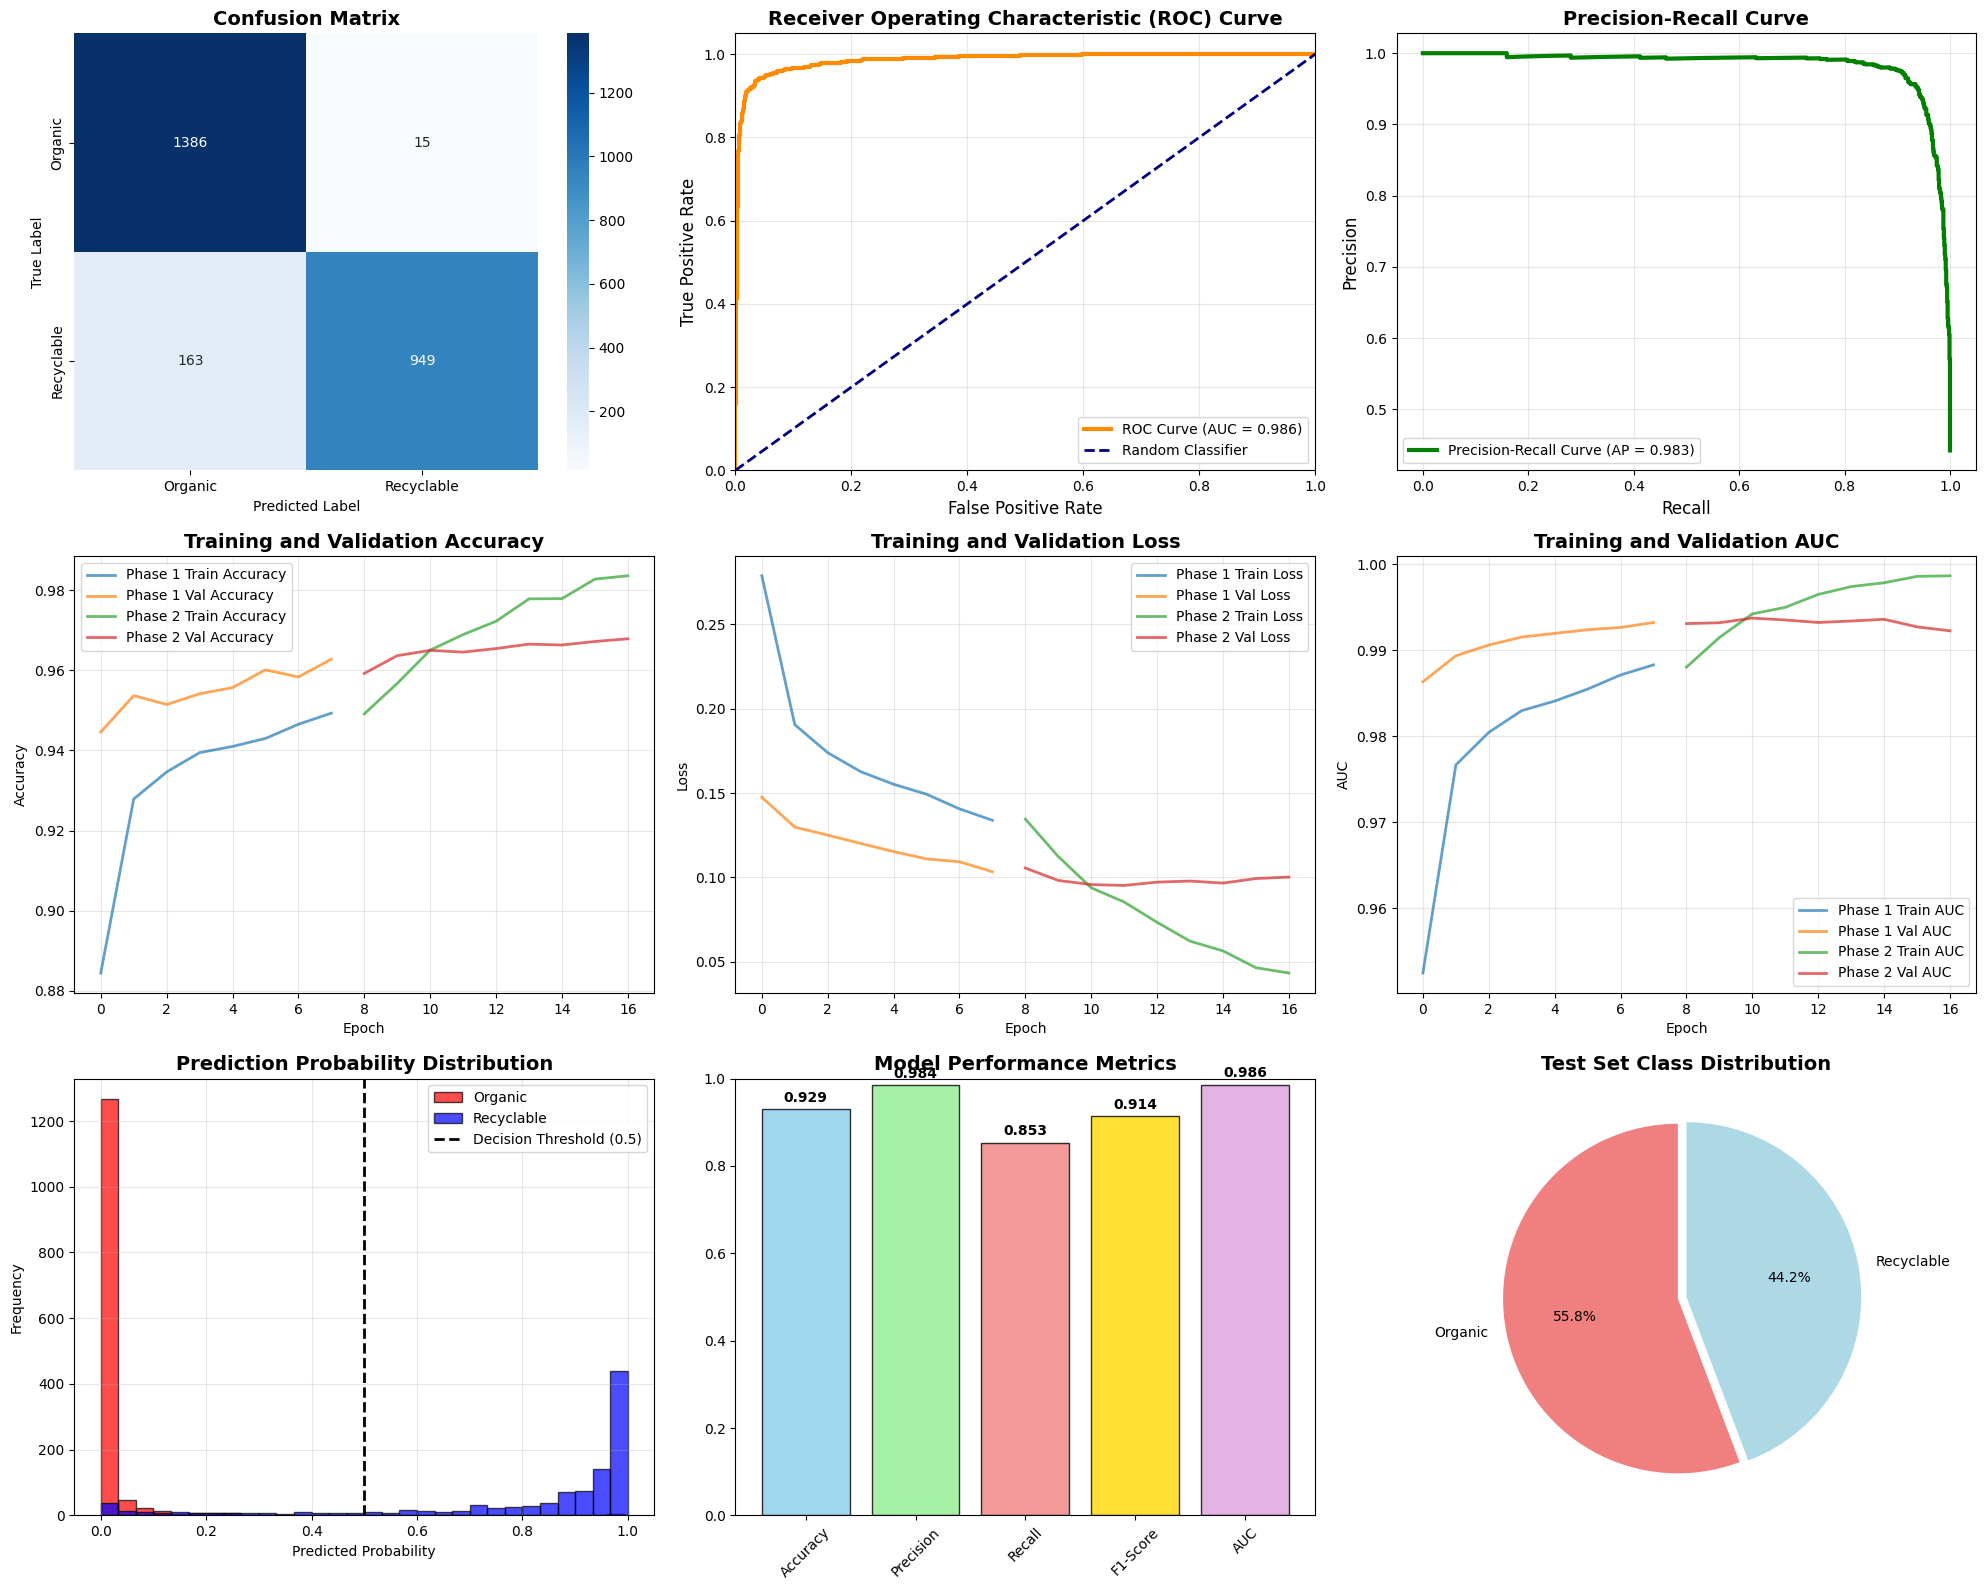

✅ All evaluation plots saved!


In [ ]:
# Cell 28 — Comprehensive visualization for assignment report
import seaborn as sns

plt.style.use('default')
fig = plt.figure(figsize=(20, 16))

# 1. Confusion Matrix
plt.subplot(3, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Organic', 'Recyclable'],
            yticklabels=['Organic', 'Recyclable'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# 2. ROC Curve
plt.subplot(3, 3, 2)
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# 3. Precision-Recall Curve
plt.subplot(3, 3, 3)
plt.plot(recall_vals, precision_vals, color='green', lw=3,
         label=f'Precision-Recall Curve (AP = {average_precision:.3f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)

# 4. Training History - Accuracy
plt.subplot(3, 3, 4)
plt.plot(history1.history['accuracy'], label='Phase 1 Train Accuracy', alpha=0.7, linewidth=2)
plt.plot(history1.history['val_accuracy'], label='Phase 1 Val Accuracy', alpha=0.7, linewidth=2)
plt.plot([x + len(history1.history['accuracy']) for x in range(len(history2.history['accuracy']))],
         history2.history['accuracy'], label='Phase 2 Train Accuracy', alpha=0.7, linewidth=2)
plt.plot([x + len(history1.history['val_accuracy']) for x in range(len(history2.history['val_accuracy']))],
         history2.history['val_accuracy'], label='Phase 2 Val Accuracy', alpha=0.7, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# 5. Training History - Loss
plt.subplot(3, 3, 5)
plt.plot(history1.history['loss'], label='Phase 1 Train Loss', alpha=0.7, linewidth=2)
plt.plot(history1.history['val_loss'], label='Phase 1 Val Loss', alpha=0.7, linewidth=2)
plt.plot([x + len(history1.history['loss']) for x in range(len(history2.history['loss']))],
         history2.history['loss'], label='Phase 2 Train Loss', alpha=0.7, linewidth=2)
plt.plot([x + len(history1.history['val_loss']) for x in range(len(history2.history['val_loss']))],
         history2.history['val_loss'], label='Phase 2 Val Loss', alpha=0.7, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# 6. Training History - AUC
plt.subplot(3, 3, 6)
plt.plot(history1.history['auc'], label='Phase 1 Train AUC', alpha=0.7, linewidth=2)
plt.plot(history1.history['val_auc'], label='Phase 1 Val AUC', alpha=0.7, linewidth=2)
plt.plot([x + len(history1.history['auc']) for x in range(len(history2.history['auc']))],
         history2.history['auc'], label='Phase 2 Train AUC', alpha=0.7, linewidth=2)
plt.plot([x + len(history1.history['val_auc']) for x in range(len(history2.history['val_auc']))],
         history2.history['val_auc'], label='Phase 2 Val AUC', alpha=0.7, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.title('Training and Validation AUC', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# 7. Probability Distribution
plt.subplot(3, 3, 7)
plt.hist(y_pred_proba[y_true == 0], bins=30, alpha=0.7, label='Organic', color='red', edgecolor='black')
plt.hist(y_pred_proba[y_true == 1], bins=30, alpha=0.7, label='Recyclable', color='blue', edgecolor='black')
plt.axvline(0.5, color='black', linestyle='--', label='Decision Threshold (0.5)', linewidth=2)
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.title('Prediction Probability Distribution', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# 8. Metrics Comparison Bar Chart
plt.subplot(3, 3, 8)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
values = [accuracy, precision, recall, f1, roc_auc]
colors = ['skyblue', 'lightgreen', 'lightcoral', 'gold', 'plum']
bars = plt.bar(metrics, values, color=colors, alpha=0.8, edgecolor='black')
plt.ylim(0, 1)
plt.title('Model Performance Metrics', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
# Add value labels on bars
for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# 9. Class Distribution
plt.subplot(3, 3, 9)
class_counts = [np.sum(y_true == 0), np.sum(y_true == 1)]
plt.pie(class_counts, labels=['Organic', 'Recyclable'], autopct='%1.1f%%',
        colors=['lightcoral', 'lightblue'], startangle=90, explode=(0.05, 0))
plt.title('Test Set Class Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "comprehensive_evaluation.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ All evaluation plots saved!")

In [ ]:
# Cell 29 — Detailed performance analysis for assignment report
print("📋 DETAILED PERFORMANCE ANALYSIS")
print("="*60)

# Calculate per-class metrics manually
tn, fp, fn, tp = cm.ravel()

print("\n📊 CONFUSION MATRIX BREAKDOWN:")
print(f"True Negatives (Organic correctly classified): {tn}")
print(f"False Positives (Organic misclassified as Recyclable): {fp}")
print(f"False Negatives (Recyclable misclassified as Organic): {fn}")
print(f"True Positives (Recyclable correctly classified): {tp}")

# Calculate additional metrics
sensitivity = tp / (tp + fn)  # Recall for recyclable
specificity = tn / (tn + fp)  # Recall for organic
false_positive_rate = fp / (fp + tn)
false_negative_rate = fn / (fn + tp)

print("\n🧮 ADDITIONAL METRICS:")
print(f"Sensitivity (True Positive Rate): {sensitivity:.4f}")
print(f"Specificity (True Negative Rate): {specificity:.4f}")
print(f"False Positive Rate: {false_positive_rate:.4f}")
print(f"False Negative Rate: {false_negative_rate:.4f}")

# Model comparison table (if you had multiple models)
print("\n📈 MODEL PERFORMANCE SUMMARY:")
models_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC', 'Avg Precision'],
    'ResNet50': [f"{accuracy:.4f}", f"{precision:.4f}", f"{recall:.4f}", f"{f1:.4f}", f"{roc_auc:.4f}", f"{average_precision:.4f}"]
}

comparison_df = pd.DataFrame(models_data)
print(comparison_df.to_string(index=False))

# Save detailed metrics to file
metrics_dict = {
    'accuracy': float(accuracy),
    'precision': float(precision),
    'recall': float(recall),
    'f1_score': float(f1),
    'roc_auc': float(roc_auc),
    'average_precision': float(average_precision),
    'sensitivity': float(sensitivity),
    'specificity': float(specificity),
    'false_positive_rate': float(false_positive_rate),
    'false_negative_rate': float(false_negative_rate),
    'confusion_matrix': cm.tolist(),
    'class_distribution': {
        'organic': int(np.sum(y_true == 0)),
        'recyclable': int(np.sum(y_true == 1))
    }
}

with open(OUTPUT_DIR / "detailed_metrics.json", "w") as f:
    json.dump(metrics_dict, f, indent=4)

print(f"\n💾 Detailed metrics saved to: {OUTPUT_DIR / 'detailed_metrics.json'}")

📋 DETAILED PERFORMANCE ANALYSIS

📊 CONFUSION MATRIX BREAKDOWN:
True Negatives (Organic correctly classified): 1386
False Positives (Organic misclassified as Recyclable): 15
False Negatives (Recyclable misclassified as Organic): 163
True Positives (Recyclable correctly classified): 949

🧮 ADDITIONAL METRICS:
Sensitivity (True Positive Rate): 0.8534
Specificity (True Negative Rate): 0.9893
False Positive Rate: 0.0107
False Negative Rate: 0.1466

📈 MODEL PERFORMANCE SUMMARY:
       Metric ResNet50
     Accuracy   0.9292
    Precision   0.9844
       Recall   0.8534
     F1-Score   0.9143
      ROC AUC   0.9861
Avg Precision   0.9833

💾 Detailed metrics saved to: /content/drive/MyDrive/SE4050/assignment/output/detailed_metrics.json


📈 LEARNING CURVE ANALYSIS


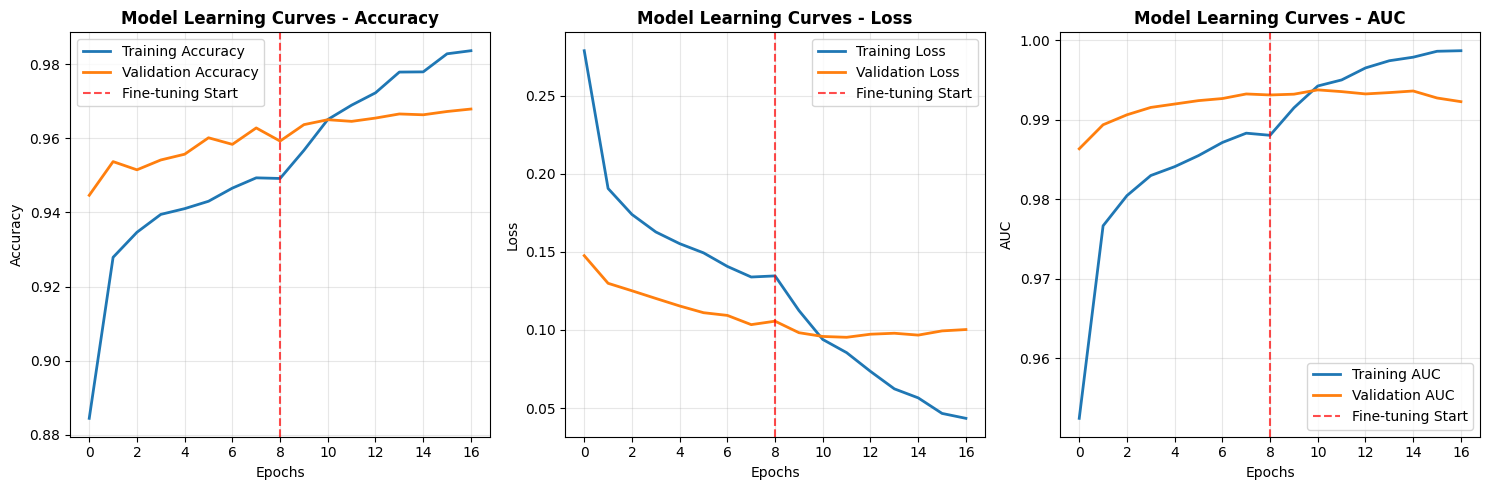


📊 FINAL TRAINING RESULTS:
Final Training Accuracy: 0.9836
Final Validation Accuracy: 0.9679
Final Training Loss: 0.0434
Final Validation Loss: 0.1003
Final Training AUC: 0.9987
Final Validation AUC: 0.9923
Generalization Gap (Val Acc - Train Acc): -0.0157
✅ Good generalization performance!


In [ ]:
# Cell 30 — Learning curve analysis
print("📈 LEARNING CURVE ANALYSIS")
print("="*50)

# Create learning curves figure
plt.figure(figsize=(15, 5))

# Combine training histories
combined_history = {
    'loss': history1.history['loss'] + history2.history['loss'],
    'accuracy': history1.history['accuracy'] + history2.history['accuracy'],
    'val_loss': history1.history['val_loss'] + history2.history['val_loss'],
    'val_accuracy': history1.history['val_accuracy'] + history2.history['val_accuracy'],
    'auc': history1.history['auc'] + history2.history['auc'],
    'val_auc': history1.history['val_auc'] + history2.history['val_auc']
}

# Plot learning curves
plt.subplot(1, 3, 1)
plt.plot(combined_history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(combined_history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.axvline(len(history1.history['accuracy']), color='red', linestyle='--',
            label='Fine-tuning Start', alpha=0.7)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Learning Curves - Accuracy', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(combined_history['loss'], label='Training Loss', linewidth=2)
plt.plot(combined_history['val_loss'], label='Validation Loss', linewidth=2)
plt.axvline(len(history1.history['loss']), color='red', linestyle='--',
            label='Fine-tuning Start', alpha=0.7)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Learning Curves - Loss', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(combined_history['auc'], label='Training AUC', linewidth=2)
plt.plot(combined_history['val_auc'], label='Validation AUC', linewidth=2)
plt.axvline(len(history1.history['auc']), color='red', linestyle='--',
            label='Fine-tuning Start', alpha=0.7)
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.title('Model Learning Curves - AUC', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "learning_curves.png", dpi=300, bbox_inches='tight')
plt.show()

# Analyze training progress
final_train_acc = combined_history['accuracy'][-1]
final_val_acc = combined_history['val_accuracy'][-1]
final_train_loss = combined_history['loss'][-1]
final_val_loss = combined_history['val_loss'][-1]
final_train_auc = combined_history['auc'][-1]
final_val_auc = combined_history['val_auc'][-1]

print(f"\n📊 FINAL TRAINING RESULTS:")
print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")
print(f"Final Training AUC: {final_train_auc:.4f}")
print(f"Final Validation AUC: {final_val_auc:.4f}")
print(f"Generalization Gap (Val Acc - Train Acc): {final_val_acc - final_train_acc:.4f}")

# Check for overfitting
if final_val_acc < final_train_acc - 0.1:
    print("⚠️  Potential overfitting detected!")
elif final_val_acc > final_train_acc:
    print("✅ Excellent generalization - Validation better than training!")
else:
    print("✅ Good generalization performance!")